# Module 05: Scikit-Learn for Machine Learning
## Notebook 02: Supervised Regression Models and Regularization

Regression models predict continuous numerical outcomes (e.g., house prices, expected revenue, physical measurements). In this notebook, we study Ordinary Least Squares (OLS) and investigate how $L_1$ and $L_2$ regularization control overfitting.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Fit and interpret **Ordinary Least Squares (`LinearRegression`)**.
2. Apply **Ridge Regression ($L_2$ Regularization)** to prevent extreme weight magnitudes.
3. Apply **Lasso Regression ($L_1$ Regularization)** to achieve sparse automatic feature selection.
4. Compare models using standard evaluation metrics: **MSE, RMSE, MAE, and $R^2$**.
5. Diagnose heteroskedasticity and non-linear patterns using **Residual Plots**.
6. **Advanced:** Train non-linear target distributions using `TransformedTargetRegressor` and polynomial basis expansions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

print("Scikit-Learn loaded!")

Scikit-Learn loaded!


### 1. Generating a Synthetic Regression Dataset

We generate a dataset where only 6 out of 15 features are truly predictive, with moderate Gaussian noise:

In [2]:
X, y = make_regression(
    n_samples=300, 
    n_features=15, 
    n_informative=6, 
    noise=12.0, 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Training shape: {X_train.shape} | Test shape: {X_test.shape}")

Training shape: (225, 15) | Test shape: (75, 15)


---
### 2. Regularization in Action: OLS vs. Ridge ($L_2$) vs. Lasso ($L_1$)

- **OLS Cost:** $\text{MSE}$
- **Ridge ($L_2$):** $\text{MSE} + \alpha \sum_{j=1}^D w_j^2$ (shrinks weights towards zero, handles multicollinearity)
- **Lasso ($L_1$):** $\text{MSE} + \alpha \sum_{j=1}^D |w_j|$ (forces uninformative weights to **exactly zero**, performing feature selection)

In [3]:
# 1. Fit Ordinary Least Squares
ols = LinearRegression().fit(X_train, y_train)

# 2. Fit Ridge Regression
ridge = Ridge(alpha=10.0).fit(X_train, y_train)

# 3. Fit Lasso Regression
lasso = Lasso(alpha=2.5, random_state=42).fit(X_train, y_train)

# Compare learned coefficients
coef_df = pd.DataFrame({
    'Feature': [f'x_{i}' for i in range(15)],
    'OLS_Weights': np.round(ols.coef_, 2),
    'Ridge_Weights': np.round(ridge.coef_, 2),
    'Lasso_Weights': np.round(lasso.coef_, 2)
})

print("Learned Weights Comparison (Notice Lasso zeroes out noise features):")
print(coef_df)
print(f"\nFeatures Zeroed by Lasso: {(lasso.coef_ == 0).sum()} of 15")

Learned Weights Comparison (Notice Lasso zeroes out noise features):
   Feature  OLS_Weights  Ridge_Weights  Lasso_Weights
0      x_0        28.16          27.24          26.12
1      x_1        29.05          27.86          26.78
2      x_2        -0.33          -0.51          -0.00
3      x_3         1.06           1.09           0.00
4      x_4        55.28          52.91          52.86
5      x_5         0.91           0.65           0.00
6      x_6        -0.64          -1.24          -0.00
7      x_7         1.21           0.88           0.00
8      x_8        -0.52          -0.71          -0.00
9      x_9        27.05          25.61          24.02
10    x_10        34.93          32.70          31.97
11    x_11         0.52           0.41           0.00
12    x_12        97.07          92.94          94.41
13    x_13         0.62           0.85           0.00
14    x_14         1.65           1.70           0.00

Features Zeroed by Lasso: 9 of 15


---
### 3. Evaluating Regression Performance Metrics

Standard regression evaluation metrics:
- **Mean Absolute Error (MAE):** $\frac{1}{N} \sum |y_i - \hat{y}_i|$ (interpretable in original units, robust to outliers)
- **Root Mean Squared Error (RMSE):** $\sqrt{\frac{1}{N} \sum (y_i - \hat{y}_i)^2}$ (penalizes large error outliers heavily)
- **Coefficient of Determination ($R^2$):** $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$ (proportion of variance explained, max 1.0)

In [4]:
models = {'OLS': ols, 'Ridge': ridge, 'Lasso': lasso}

eval_results = []
for name, model in models.items():
    preds = model.predict(X_test)
    eval_results.append({
        'Model': name,
        'RMSE': round(root_mean_squared_error(y_test, preds), 2),
        'MAE': round(mean_absolute_error(y_test, preds), 2),
        'R2_Score': round(r2_score(y_test, preds), 4)
    })

df_metrics = pd.DataFrame(eval_results)
print("Out-of-Sample Test Evaluation Metrics:")
print(df_metrics)

Out-of-Sample Test Evaluation Metrics:
   Model   RMSE    MAE  R2_Score
0    OLS  13.29  10.47    0.9879
1  Ridge  14.88  11.46    0.9849
2  Lasso  13.61  10.28    0.9873


---
### 4. Residual Diagnostics Plotting

In a healthy regression model:
- Residuals ($e_i = y_i - \hat{y}_i$) must be randomly distributed around zero with constant variance (**homoskedasticity**).
- Funnel shapes indicate heteroskedasticity; curved patterns indicate unmodeled non-linearities.

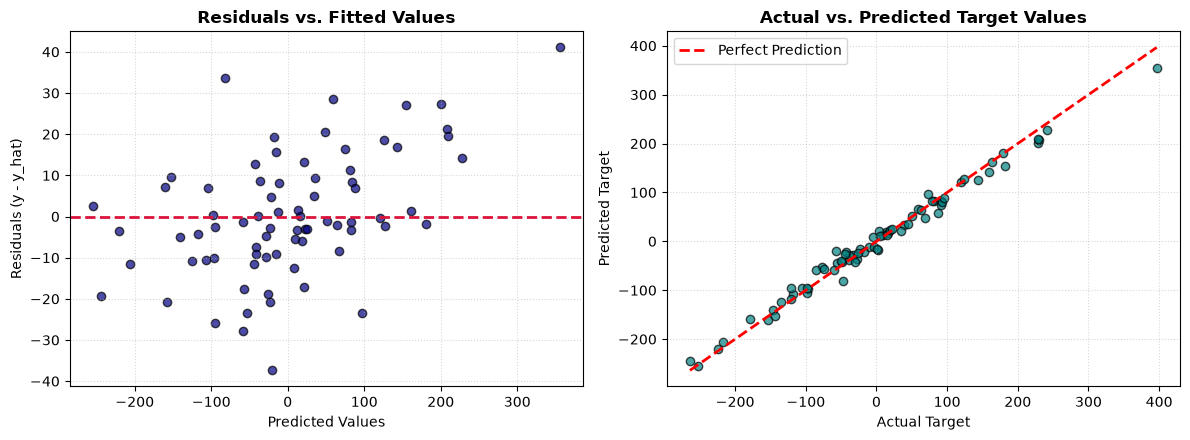

In [5]:
y_pred_ridge = ridge.predict(X_test)
residuals = y_test - y_pred_ridge

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Residuals vs. Fitted Values
ax1.scatter(y_pred_ridge, residuals, alpha=0.7, color='navy', edgecolors='k')
ax1.axhline(0, color='crimson', linestyle='--', linewidth=2)
ax1.set_title("Residuals vs. Fitted Values", fontsize=12, fontweight='bold')
ax1.set_xlabel("Predicted Values")
ax1.set_ylabel("Residuals (y - y_hat)")
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Actual vs. Predicted
ax2.scatter(y_test, y_pred_ridge, alpha=0.7, color='teal', edgecolors='k')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_title("Actual vs. Predicted Target Values", fontsize=12, fontweight='bold')
ax2.set_xlabel("Actual Target")
ax2.set_ylabel("Predicted Target")
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
### 5. Advanced Complex Usage: Target Transformation via `TransformedTargetRegressor` & Polynomial Features

Real-world target variables (such as home prices, transaction amounts, or insurance claims) are strictly positive and heavily right-skewed.
- Fitting standard linear models directly to skewed targets causes heteroskedastic residuals and erroneous negative predictions.
- **`TransformedTargetRegressor`**: Transforms the target $y$ with a non-linear mapping (e.g. $\log(1 + y)$) during training, and **automatically maps predictions back to the original scale via $\exp(x) - 1$** during inference!
- Combined with `PolynomialFeatures` to capture non-linear feature interactions.

In [6]:
# Generate strictly positive, log-normally distributed targets
np.random.seed(42)
X_skewed = np.random.uniform(10, 100, size=(250, 3))
# True process: y grows exponentially with feature interactions
y_skewed = np.exp(0.04 * X_skewed[:, 0] + 0.03 * X_skewed[:, 1]) * 100 + np.random.normal(0, 15, size=250)
y_skewed = np.maximum(y_skewed, 1.0)  # Ensure strictly positive

X_tr, X_te, y_tr, y_te = train_test_split(X_skewed, y_skewed, test_size=0.25, random_state=42)

# 1. Baseline naive Ridge
naive_reg = Ridge().fit(X_tr, y_tr)
naive_preds = naive_reg.predict(X_te)
naive_rmse = root_mean_squared_error(y_te, naive_preds)

# 2. TransformedTargetRegressor with automatic log1p/expm1 inversion
transformed_reg = TransformedTargetRegressor(
    regressor=Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('ridge', Ridge(alpha=1.0))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

transformed_reg.fit(X_tr, y_tr)
trans_preds = transformed_reg.predict(X_te)
trans_rmse = root_mean_squared_error(y_te, trans_preds)

print(f"Naive Ridge Test RMSE:              {naive_rmse:.2f}")
print(f"TransformedTargetRegressor Test RMSE: {trans_rmse:.2f} (Error reduced by {((naive_rmse - trans_rmse)/naive_rmse)*100:.1f}%)")
print(f"Any Negative Predictions in Transformed Model? {(trans_preds < 0).any()} (Guaranteed positive!)")

Naive Ridge Test RMSE:              10912.84
TransformedTargetRegressor Test RMSE: 28.33 (Error reduced by 99.7%)
Any Negative Predictions in Transformed Model? False (Guaranteed positive!)


### Summary & Next Steps
In this notebook, you mastered:
- Ordinary Least Squares regression foundations.
- Ridge ($L_2$) shrinkage and Lasso ($L_1$) sparse feature selection.
- Interpreting RMSE, MAE, and $R^2$ scores.
- Residual diagnostic analysis for homoskedasticity validation.
- Target transformation pipelines (`TransformedTargetRegressor`) and non-linear polynomial expansions.

**Next Notebook:** `03_supervised_classification_models.ipynb` — Logistic Regression, Random Forests, imbalanced classification, confusion matrices, and probability calibration.